# Using `isoc` for isochrone retrieval

`isoc` queries and processes stellar isochrone data from the [Padova/PARSEC](https://stev.oapd.inaf.it/cgi-bin/cmd) and the [MIST/MESA](https://mist.science/interp_isos.html) databases. In effect it fills out the relevant webform for you and returns the result not as a text file but as an `Isochrone` object that stores all data in [astropy tables](https://docs.astropy.org/en/stable/table/index.html) with physical units. `Isochrone` has two main properties - `data` and `photometry` - as well as secondary properties for quick access to data columns such as `log_age`, `mass` and `metallicity`.

This tutorial is divided into sections:

1. [Querying](#1.-Querying) — getting an `Isochrone`
2. [Data](#2.-Data) — data tables and useful shorthands in `Isochrone`
3. [Photometry](#3.-Photometry) — accessing photometric systems in `Isochrone`
     - [3.1: Computing colors](#3.1-Computing-colors)
     - [3.2: Adding multiple photometric systems to a dataset](#3.2-Adding-multiple-photometric-systems-to-data)
4. [Plotting](#4.-Plotting) — a few basic examples, including:
     - [4.1: Comparing Padova/PARSEC and MIST/MESA isochrones on an H-R diagram](#4.1:-Comparing-Padova/PARSEC-and-MIST/MESA-isochrones-on-an-H-R-diagram)
     - [4.2: Plotting over a grid of ages or metallicities](#4.2:-Plotting-over-a-grid-of-ages)
     - [4.3: A color-magnitude diagram](#4.3:-Color-magnitude-diagram)
5. [Parameter help](#5.-Parameter-help) — for `Isochrone.from_mist` and `Isochrone.from_padova`

## 1. Querying

In [1]:
# avoid need to add `print` to all but the last call in a cell
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

Query the MIST/MESA and Padova/PARSEC databases with `Isochrone.from_mist` and `Isochrone.from_padova`, like this:

In [2]:
from isoc.isochrone import Isochrone

In [3]:
im = Isochrone.from_mist(
    age=1e9,
    metallicity=0.0,
    photometry="JWST NIRCAM",
    )

Inferred linear age scale based on age values 1000000000.0.
Querying https://mist.science/iso_form.php
Query parameters sent to the MIST server:
	version=MIST2
	v_div_vcrit=vvcrit0.4
	FeH_value=0.0
	alpha_value=p0
	age_type=single
	age_scale=linear
	age_value=1000000000.0
	age_range_low=5
	age_range_high=10.3
	age_range_delta=0.05
	output_option=photometry
	output=JWST
	Av_value=0
Zip archive contains: ['MIST_iso_69b35d1f4b060.iso', 'MIST_iso_69b35d1f4b060.iso.JWST']
Parsing theory file: MIST_iso_69b35d1f4b060.iso
Parsing photometry file: MIST_iso_69b35d1f4b060.iso.JWST
  Moving theory column '[Fe/H]_init' from photometry file to theory table.
  Moving theory column '[Fe/H]' from photometry file to theory table.
Theory file has 172 columns, photometry file has 40 columns, identified 29 photometry-only columns: ['NIRCAM_F070W', 'NIRCAM_F090W', 'NIRCAM_F115W', 'NIRCAM_F140W', 'NIRCAM_F150W', 'NIRCAM_F150W2', 'NIRCAM_F162M', 'NIRCAM_F164N', 'NIRCAM_F182M', 'NIRCAM_F187N', 'NIRCAM_F200W', 

Or for Padova/PARSEC:

In [4]:
# age=9 is interpreted as log10(age/yr) = 9
# Z=0.0207 is solar metallicity
ip = Isochrone.from_padova(
    age=9,
    metallicity=0.0207,
    metallicity_type="Z",
    photometry="Euclid VIS+NISP (ABmags)",
    )

Inferred log10 age scale based on age values (9.0, 9.0, 0.0).


Querying http://stev.oapd.inaf.it/cgi-bin/cmd...
Retrieving data...
User-supplied query parameters (as seen by ezpadova):
	{'age_yr': None, 'logage': (9.0, 9.0, 0.0), 'Z': (0.0207, 0.0207, 0.0), 'MH': None, 'photsys_file': 'euclid_nisp'}
All query parameters (including defaults for those not specified):
	{'age_yr': None, 'logage': (9.0, 9.0, 0.0), 'Z': (0.0207, 0.0207, 0.0), 'MH': None, 'photsys_file': 'euclid_nisp', 'cmd_version': '3.8', 'track_omegai': '0.00', 'track_parsec': 'parsec_CAF09_v1.2S', 'track_colibri': 'parsec_CAF09_v1.2S_S_LMC_08_web', 'track_postagb': 'no', 'n_inTPC': '10', 'eta_reimers': '0.2', 'kind_interp': '1', 'kind_postagb': '-1', 'photsys_version': 'YBCnewVega', 'dust_sourceM': 'dpmod60alox40', 'dust_sourceC': 'AMCSIC15', 'kind_mag': '2', 'kind_dust': '0', 'extinction_av': '0.0', 'extinction_coeff': 'constant', 'extinction_curve': 'cardelli', 'kind_LPV': '3', 'imf_file': 'tab_imf/imf_kroupa_orig.dat'

If you prefer the `ezpadova.get_isochrones` [argument style](https://github.com/mfouesneau/ezpadova/blob/f39625883e22a619b180c73b290a46a2a137f05e/src/ezpadova/parsec.py#L147), that works too:

In [5]:
# equivalent to the above call with `from_padova`
ip_ez = Isochrone.query_ezpadova(
    logage=(9,9,0),
    Z=(0.0207,0.0207,0),
    photsys_file="euclid_nisp",
    )

Querying http://stev.oapd.inaf.it/cgi-bin/cmd...
Retrieving data...
User-supplied query parameters (as seen by ezpadova):
	{'age_yr': None, 'logage': (9.0, 9.0, 0.0), 'Z': (0.0207, 0.0207, 0.0), 'MH': None, 'photsys_file': 'euclid_nisp'}
All query parameters (including defaults for those not specified by user):
	{'age_yr': None, 'logage': (9.0, 9.0, 0.0), 'Z': (0.0207, 0.0207, 0.0), 'MH': None, 'photsys_file': 'euclid_nisp', 'cmd_version': '3.8', 'track_omegai': '0.00', 'track_parsec': 'parsec_CAF09_v1.2S', 'track_colibri': 'parsec_CAF09_v1.2S_S_LMC_08_web', 'track_postagb': 'no', 'n_inTPC': '10', 'eta_reimers': '0.2', 'kind_interp': '1', 'kind_postagb': '-1', 'photsys_version': 'YBCnewVega', 'dust_sourceM': 'dpmod60alox40', 'dust_sourceC': 'AMCSIC15', 'kind_mag': '2', 'kind_dust': '0', 'extinction_av': '0.0', 'extinction_coeff': 'constant', 'extinction_curve': 'cardelli', 'kind_LPV': '3', 'imf_file': 'tab_imf/imf_kroupa_orig.dat', 'isoc_isagelog': '0', 'isoc_agelow': '1.0e9', 'isoc_ag

Or instead of querying, you can load a local isochrone file:

In [6]:
# load a mist file from a query over a grid of ages, including photometry
im_local = Isochrone.from_mist(from_file="data_files/mist_multiple.zip")

print("\n")

# load a padova file for a single isochrone, including photometry
ip_local = Isochrone.from_padova(from_file="data_files/padova_single.dat")

'from_file' is not None. Loading isochrone data from file: data_files/mist_multiple.zip rather than performing a query.
Zip archive contains: ['MIST_iso_69b030f63c54a.iso', 'MIST_iso_69b030f63c54a.iso.SDSSugriz']
Parsing theory file: MIST_iso_69b030f63c54a.iso
Parsing photometry file: MIST_iso_69b030f63c54a.iso.SDSSugriz
  Moving theory column '[Fe/H]_init' from photometry file to theory table.
  Moving theory column '[Fe/H]' from photometry file to theory table.
Theory file has 172 columns, photometry file has 16 columns, identified 5 photometry-only columns: ['SDSS_u', 'SDSS_g', 'SDSS_r', 'SDSS_i', 'SDSS_z']


'from_file' is not None. Loading isochrone data from file: data_files/padova_single.dat rather than performing a query.


## 2. Data

The data in `Isochrone` is stored in astropy tables with physical units. All non-photometric data is in `Isochrone.data`. For the Padova/PARSEC isochrone queried above, we can get an overview of the data at multiple levels:

In [7]:
ip

Isochrone(database=padova): 533 rows x 27 columns

In [8]:
ip.columns

<TableColumns names=('Zini','MH','logAge','Mini','int_IMF','Mass','logL','logTe','logg','label','McoreTP','C_O','period0','period1','period2','period3','period4','pmode','Mloss','tau1m','X','Y','Xc','Xn','Xo','Cexcess','Z')>

In [9]:
ip.data

Zini,MH,logAge,Mini,int_IMF,Mass,logL,logTe,logg,label,McoreTP,C_O,period0,period1,period2,period3,period4,pmode,Mloss,tau1m,X,Y,Xc,Xn,Xo,Cexcess,Z
,dex,dex(yr),solMass,,solMass,dex(solLum),dex(K),dex(cm / s2),,solMass,,d,d,d,d,d,,solMass / yr,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0.0207,0.15867,9.0,0.0908484459,1.0897678296,0.091,-3.376,3.3592,5.161,0.0,0.0,0.545,0.0,0.0,0.0,0.0,0.0,-1.0,-4.66e-17,0.0,0.6935,0.2856,0.003749,0.001011,0.009172,-1.0,0.02085
0.0207,0.15867,9.0,0.1008355916,1.1780487038,0.101,-3.231,3.3795,5.143,0.0,0.0,0.545,0.0,0.0,0.0,0.0,0.0,-1.0,-6.29e-17,0.0,0.6935,0.2857,0.003749,0.001011,0.009172,-1.0,0.02085
0.0207,0.15867,9.0,0.1086777225,1.2397594949,0.109,-3.146,3.3911,5.136,0.0,0.0,0.545,0.0,0.0,0.0,0.0,0.0,-1.0,-7.42e-17,0.0,0.6935,0.2857,0.003749,0.001011,0.009172,-1.0,0.02085
0.0207,0.15867,9.0,0.113472119,1.2747051904,0.113,-3.092,3.3982,5.129,0.0,0.0,0.545,0.0,0.0,0.0,0.0,0.0,-1.0,-8.27e-17,0.0,0.6935,0.2857,0.003749,0.001011,0.009172,-1.0,0.02085
0.0207,0.15867,9.0,0.1183084249,1.3080637026,0.118,-3.036,3.4053,5.119,0.0,0.0,0.545,0.0,0.0,0.0,0.0,0.0,-1.0,-9.31e-17,0.0,0.6935,0.2857,0.003749,0.001011,0.009172,-1.0,0.02085
0.0207,0.15867,9.0,0.1208098754,1.3246297029,0.121,-3.008,3.4088,5.115,0.0,0.0,0.545,0.0,0.0,0.0,0.0,0.0,-1.0,-9.86e-17,0.0,0.6934,0.2857,0.003749,0.001011,0.009172,-1.0,0.02085
0.0207,0.15867,9.0,0.1407841742,1.4426669988,0.141,-2.826,3.43,5.084,0.0,0.0,0.545,0.0,0.0,0.0,0.0,0.0,-1.0,-1.44e-16,0.0,0.6934,0.2858,0.003749,0.001011,0.009172,-1.0,0.02085
0.0207,0.15867,9.0,0.1423892677,1.4511987412,0.142,-2.814,3.4312,5.082,0.0,0.0,0.545,0.0,0.0,0.0,0.0,0.0,-1.0,-1.48e-16,0.0,0.6934,0.2858,0.003749,0.001011,0.009172,-1.0,0.02085


Or for the MIST `Isochrone`:

In [10]:
im.data

EEP,isochrone_age_yr,initial_mass,star_mass,star_mdot,he_core_mass,c_core_mass,o_core_mass,log_L,log_L_div_Ledd,log_LH,log_LHe,log_LZ,log_Teff,log_abs_Lgrav,log_R,log_g,log_surf_cell_z,surf_avg_omega,surf_avg_v_rot,surf_num_c12_div_num_o16,surf_avg_omega_crit,surf_avg_omega_div_omega_crit,surf_avg_v_crit,surf_avg_v_div_v_crit,surf_avg_Lrad_div_Ledd,v_div_csound_surf,surf_r_equatorial_div_r,surf_r_polar_div_r,total_angular_momentum,grav_dark_L_polar,grav_dark_Teff_polar,grav_dark_L_equatorial,grav_dark_Teff_equatorial,surface_h1,surface_h2,surface_he3,surface_he4,surface_li7,surface_be7,surface_be9,surface_be10,surface_b8,surface_c12,surface_c13,surface_n13,surface_n14,surface_n15,surface_o14,surface_o15,surface_o16,surface_o17,surface_o18,surface_f17,surface_f18,surface_f19,surface_ne18,surface_ne19,surface_ne20,surface_ne21,surface_ne22,surface_na21,surface_na22,surface_na23,surface_na24,surface_mg23,surface_mg24,surface_mg25,surface_mg26,surface_al25,surface_al26,surface_al27,surface_si27,surface_si28,surface_si29,surface_si30,surface_p30,surface_p31,surface_s31,surface_s32,surface_s33,surface_s34,surface_ca40,surface_ti48,surface_fe56,log_center_T,log_center_Rho,center_degeneracy,center_omega,center_gamma,mass_conv_core,center_h1,center_h2,center_he3,center_he4,center_li7,center_be7,center_be9,center_be10,center_b8,center_c12,center_c13,center_n13,center_n14,center_n15,center_o14,center_o15,center_o16,center_o17,center_o18,center_f17,center_f18,center_f19,center_ne18,center_ne19,center_ne20,center_ne21,center_ne22,center_na21,center_na22,center_na23,center_na24,center_mg23,center_mg24,center_mg25,center_mg26,center_al25,center_al26,center_al27,center_si27,center_si28,center_si29,center_si30,center_p30,center_p31,center_s31,center_s32,center_s33,center_s34,center_ca40,center_ti48,center_fe56,pp,cno,tri_alfa,burn_c,burn_n,burn_o,c12_c12,apsidal_constant_k2,delta_nu,delta_Pg,nu_max,acoustic_cutoff,max_conv_vel_div_csound,max_gradT_div_grada,gradT_excess_alpha,min_Pgas_div_P,max_L_rad_div_Ledd,e_thermal,conv_env_top_mass,conv_env_bot_mass,conv_env_top_radius,conv_env_bot_radius,conv_env_turnover_time_l_t,conv_env_turnover_time_l_b,conv_env_turnover_time_g,envelope_binding_energy,total_moment_of_inertia,phase,[Fe/H]_init,[Fe/H]
,,solMass,solMass,solMass / yr,solMass,solMass,solMass,dex(solLum),dex,dex(solLum),dex(solLum),dex(solLum),dex(K),dex(solLum),dex(solRad),dex(cm / s2),dex,rad / s,km / s,,rad / s,,km / s,,,,,,cm2 g / s,solLum,K,solLum,K,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,dex(K),dex(g / cm3),,rad / s,,solMass,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,dex(solLum),dex(solLum),dex(solLum),dex(solLum),dex(solLum),dex(solLum),dex(solLum),,uHz,s,uHz,uHz,,,,,,erg,solMass,solMass,solRad,solRad,s,s,s,erg,cm2 g,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

Access columns in the data with their titles:

In [11]:
ip.data["Mini"]

<Quantity [0.09084845, 0.10083559, 0.10867772, 0.11347212, 0.11830842,
           0.12080988, 0.14078417, 0.14238927, 0.14607579, 0.16075844,
           0.19872212, 0.20070703, 0.20233124, 0.25064275, 0.31017524,
           0.31422621, 0.3485764 , 0.35051423, 0.40044996, 0.45038566,
           0.47251242, 0.50032139, 0.50843978, 0.55025709, 0.57926512,
           0.60019284, 0.60846084, 0.65012848, 0.65793812, 0.7000643 ,
           0.70476967, 0.75      , 0.80000001, 0.85000002, 0.89999992,
           0.94999999, 0.98419011, 1.        , 1.01913333, 1.04999995,
           1.0999999 , 1.14999998, 1.16419482, 1.20000005, 1.20520103,
           1.22623169, 1.24999988, 1.28742218, 1.29999995, 1.35000002,
           1.39999986, 1.4348737 , 1.45000005, 1.45391548, 1.5       ,
           1.54340255, 1.54999983, 1.59870648, 1.60000002, 1.62989783,
           1.64999986, 1.66113508, 1.67499983, 1.68156803, 1.70000005,
           1.72500014, 1.74365592, 1.75      , 1.7750001 , 1.79875672,
      

Or use shorthands for the most commonly used columns:

In [12]:
# print first few values of properties
ip.log_age[:5]
ip.log_Teff[:5]
ip.initial_mass[:5]
ip.mass[:5]
ip.initial_metallicity[:5]
ip.metallicity[:5]
ip.log_g[:5]
ip.log_L[:5]

<Dex [9., 9., 9., 9., 9.] dex(yr)>

<Dex [3.3592, 3.3795, 3.3911, 3.3982, 3.4053] dex(K)>

<Quantity [0.09084845, 0.10083559, 0.10867772, 0.11347212, 0.11830842] solMass>

<Quantity [0.091, 0.101, 0.109, 0.113, 0.118] solMass>

<Quantity [0.0207, 0.0207, 0.0207, 0.0207, 0.0207]>

<Quantity [0.02085, 0.02085, 0.02085, 0.02085, 0.02085]>

<Dex [5.161, 5.143, 5.136, 5.129, 5.119] dex(cm / s2)>

<Dex [-3.376, -3.231, -3.146, -3.092, -3.036] dex(solLum)>

If the dataset has multiple isochrones (we queried over an age or metallicity grid), they're all stored in `Isochrone.data`, but we can also access them individually with `Isochrone.isochrone`:

In [13]:
print(f"Number of isochrones in MIST data: {im_local.n_isochrones}")
print(f"As individual objects: {im_local.isochrone}\n")

# get an `Isochrone` with the data only for the isochrone of log_age=9.5
im_local.isochrone[1]
# same as above
im_local.isochrone['log_age=9.5']


Number of isochrones in MIST data: 3
As individual objects: <IsochroneIndex: 3 isochrone(s): ['log_age=9', 'log_age=9.5', 'log_age=10']>



Isochrone(database=mist): 1398 rows x 172 columns

Isochrone(database=mist): 1398 rows x 172 columns

A few other `Isochrone` properties may be helpful:

In [14]:
# values used to perform the MIST query, as seen by the server
print(f"MIST query parameters\n{im.query_parameters}\n")

print(f"PARSEC query parameters\n{ip.query_parameters}\n")

# header of file downloaded from MIST query
print(f"MIST header:\n{im.header}\n")

print(f"PARSEC header:\n{ip.header}\n")

MIST query parameters
{'age': 1000000000.0, 'FeH': 0.0, 'alphaFe': None, 'v_div_vcrit': None, 'output_option': 'photometry', 'output': 'JWST', 'extinction_Av': None, 'version': None}

PARSEC query parameters
{'age_yr': None, 'logage': (9.0, 9.0, 0.0), 'Z': (0.0207, 0.0207, 0.0), 'MH': None, 'photsys_file': 'euclid_nisp', 'cmd_version': '3.8', 'track_omegai': '0.00', 'track_parsec': 'parsec_CAF09_v1.2S', 'track_colibri': 'parsec_CAF09_v1.2S_S_LMC_08_web', 'track_postagb': 'no', 'n_inTPC': '10', 'eta_reimers': '0.2', 'kind_interp': '1', 'kind_postagb': '-1', 'photsys_version': 'YBCnewVega', 'dust_sourceM': 'dpmod60alox40', 'dust_sourceC': 'AMCSIC15', 'kind_mag': '2', 'kind_dust': '0', 'extinction_av': '0.0', 'extinction_coeff': 'constant', 'extinction_curve': 'cardelli', 'kind_LPV': '3', 'imf_file': 'tab_imf/imf_kroupa_orig.dat', 'isoc_isagelog': '0', 'isoc_agelow': '1.0e9', 'isoc_ageupp': '1.0e10', 'isoc_dage': '0.0', 'isoc_lagelow': '6.6', 'isoc_lageupp': '10.13', 'isoc_dlage': '0.0', 

## 3. Photometry

Photometry data is kept separate from `Isochrone.data` and is in `Isochrone.photometry.data`. Its attributes largely mirror those in `Isochrone.data`. For example:

In [15]:
ip.photometry

<Photometry: 1 system(s): Euclid_VIS+NISP_(ABmags) (7 bands)>

(The 'system' here is the photometric system, composed of multiple bands. Data from each photometric system is stored in its own table in `Isochrone.photometry`. We'll add more photometric systems to a dataset below.)

In [16]:
ip.photometry.columns

{'Euclid_VIS+NISP_(ABmags)': ['mbolmag',
  'VISmag',
  'Ymag',
  'Bluemag',
  'Jmag',
  'Redmag',
  'Hmag']}

In [17]:
ip.photometry.data

{'Euclid_VIS+NISP_(ABmags)': <QTable length=533>
 mbolmag  VISmag   Ymag  Bluemag   Jmag   Redmag   Hmag 
   mag     mag     mag     mag     mag     mag     mag  
 float64 float64 float64 float64 float64 float64 float64
 ------- ------- ------- ------- ------- ------- -------
   13.21  14.824  12.333  12.258  12.048  11.982  11.984
  12.848  14.462  11.971  11.897  11.687  11.622  11.623
  12.635  14.249  11.758  11.683  11.474  11.409   11.41
    12.5  14.113  11.622  11.548  11.339  11.274  11.275
   12.36  13.973  11.482  11.408    11.2  11.135  11.135
  12.291  13.904  11.413  11.339  11.131  11.066  11.066
  11.835  13.267  10.959  10.893  10.689  10.628  10.631
  11.805   13.22  10.929  10.863   10.66    10.6  10.602
  11.737  13.117  10.862  10.797  10.595  10.536  10.539
     ...     ...     ...     ...     ...     ...     ...
  -4.389  -2.434  -4.995  -5.073  -5.574  -5.718  -5.859
    -4.5  -2.688  -5.087  -5.157  -5.638  -5.785  -5.928
  -4.683  -2.859  -5.077  -5.144  -5.64

In [18]:
ip.photometry.data["Ymag"]

<Quantity [ 1.2333e+01,  1.1971e+01,  1.1758e+01,  1.1622e+01,  1.1482e+01,
            1.1413e+01,  1.0959e+01,  1.0929e+01,  1.0862e+01,  1.0606e+01,
            1.0108e+01,  1.0085e+01,  1.0067e+01,  9.5960e+00,  9.1340e+00,
            9.1010e+00,  8.8580e+00,  8.8450e+00,  8.4950e+00,  8.1450e+00,
            7.9850e+00,  7.7940e+00,  7.7330e+00,  7.4390e+00,  7.2340e+00,
            7.0920e+00,  7.0340e+00,  6.7500e+00,  6.6970e+00,  6.4230e+00,
            6.3920e+00,  6.1070e+00,  5.8200e+00,  5.5480e+00,  5.2940e+00,
            5.0530e+00,  4.8950e+00,  4.8250e+00,  4.7400e+00,  4.6060e+00,
            4.3950e+00,  4.1910e+00,  4.1330e+00,  3.9930e+00,  3.9720e+00,
            3.8910e+00,  3.8030e+00,  3.6690e+00,  3.6240e+00,  3.4520e+00,
            3.2900e+00,  3.1810e+00,  3.1350e+00,  3.1230e+00,  2.9880e+00,
            2.8660e+00,  2.8470e+00,  2.7160e+00,  2.7120e+00,  2.6330e+00,
            2.5780e+00,  2.5490e+00,  2.5110e+00,  2.4930e+00,  2.4430e+00,
            

In [19]:
print(f"MIST photometry header:\n{im.photometry.header}\n")

print(f"PARSEC photometry header:\n{ip.photometry.header}\n")

MIST photometry header:
PHOTOMETRY.JWST
MIST version number  = 2.5
MESA revision number =    11701
photometric system   = JWST NIRCAM (Vega)
--------------------------------------------------------------------------------------
Yinit        Zinit   [Fe/H]   [a/Fe]  v/vcrit
0.2722  1.78798E-02     0.00     0.00     0.40
--------------------------------------------------------------------------------------
number of isochrones =     1
extinction:   Av, Rv =  0.000 3.100
--------------------------------------------------------------------------------------
number of EEPs, cols =  1401   40

PARSEC photometry header:
PHOTOMETRY.euclid_nisp
File generated by CMD 3.9 (http://stev.oapd.inaf.it/cmd) on Fri Mar 13 00:41:33 UTC 2026
isochrones based on PARSEC release v1.2S +  COLIBRI S_37 + S_35 + PR16
Basic references: Bressan et al. (2012), MNRAS, 427, 127 + Chen et al. (2014, 2015), MNRAS, 444, 2525 + MNRAS, 452, 1068 + Tang et al. (2014), MNRAS, 445, 4287 + Marigo et al. (2017), ApJ, 835, 77

### 3.1 Computing colors

Select two magnitude columns in a photometric dataset to compute a color, which will be added as a new column to the dataset:

In [20]:
# B-V color
ip_local.photometry.get_color("Bmag", "Vmag")

print(f"Updated photometry data:\n{ip_local.photometry.data}\n")

Bmag-Vmag column added to photometry table.


<Quantity [ 1.83 ,  1.823,  1.795,  1.782,  1.707,  1.68 ,  1.659,  1.602,
            1.568,  1.527,  1.522,  1.507,  1.505,  1.478,  1.448,  1.422,
            1.417,  1.403,  1.4  ,  1.375,  1.358,  1.322,  1.308,  1.193,
            1.184,  1.051,  1.044,  0.958,  0.953,  0.877,  0.81 ,  0.798,
            0.745,  0.687,  0.666,  0.632,  0.582,  0.561,  0.538,  0.496,
            0.459,  0.428,  0.423,  0.398,  0.37 ,  0.346,  0.341,  0.316,
            0.312,  0.311,  0.288,  0.286,  0.267,  0.266,  0.254,  0.249,
            0.243,  0.233,  0.225,  0.221,  0.217,  0.212,  0.212,  0.209,
            0.208,  0.207,  0.209,  0.21 ,  0.213,  0.222,  0.235,  0.251,
            0.252,  0.271,  0.294,  0.302,  0.32 ,  0.343,  0.366,  0.372,
            0.373,  0.353,  0.323,  0.293,  0.263,  0.234,  0.204,  0.174,
            0.157,  0.174,  0.199,  0.227,  0.261,  0.294,  0.329,  0.366,
            0.405,  0.444,  0.487,  0.528,  0.572,  0.621,  0.657,  0.694,
            0.724,  0.749

Updated photometry data:
{'YBC_tab_mag_odfnew/tab_mag_ubvrijhk.dat': <QTable length=638>
mbolmag   Umag    Bmag    Vmag  ...   Jmag    Hmag    Kmag       Bmag-Vmag      
  mag     mag     mag     mag   ...   mag     mag     mag           mag         
float64 float64 float64 float64 ... float64 float64 float64       float64       
------- ------- ------- ------- ... ------- ------- ------- --------------------
  13.23  22.457  19.862  18.032 ...   11.14  10.526  10.234   1.8299999999999983
 12.826  22.013   19.44  17.617 ...  10.737  10.124   9.829   1.8230000000000004
 12.208  21.023  18.583  16.788 ...  10.133    9.52    9.22   1.7949999999999982
  12.14  20.769  18.389  16.607 ...  10.073   9.459   9.159                1.782
 11.755  19.486  17.374  15.667 ...   9.727   9.112   8.812    1.706999999999999
 11.585  18.996  16.976  15.296 ...   9.572   8.956   8.657   1.6799999999999997
 11.403  18.485  16.559    14.9 ...   9.409   8.791   8.494   1.6590000000000007
 10.865  17.155  15.

### 3.2 Adding multiple photometric systems to data

To add more photometry to an existing `Isochrone`, you can first see which systems are currently in your data:

In [21]:
ip.photometry.systems

{'euclid_nisp': 'Euclid_VIS+NISP_(ABmags)'}

The key in this dictionary is the shorthand name for the system used by the web server, and the value is the name in the dropdown menu of the webform (with spaces replaced with '_').

We can see which other systems are available from the server:

In [22]:
ip.photometry.available_systems

{'2mass_spitzer': '2MASS + Spitzer (IRAC+MIPS)',
 '2mass_spitzer_wise': '2MASS + Spitzer (IRAC+MIPS) + WISE',
 '2mass': '2MASS JHKs',
 'ogle_2mass_spitzer': 'OGLE + 2MASS + Spitzer (IRAC+MIPS)',
 'ubvrijhk': 'UBVRIJHK (cf. Maiz-Apellaniz 2006 + Bessell 1990)',
 'bessell': 'UBVRIJHKLMN (cf. Bessell 1990 + Bessell & Brett 1988)',
 'akari': 'AKARI',
 'batc': 'BATC',
 'megacam_wircam': 'CFHT Megacam + Wircam (all ABmags)',
 'wircam': 'CFHT Wircam',
 'megacam_post2014': "CFHT/Megacam post-2014 u*g'r'i'z'",
 'megacam': "CFHT/Megacam pre-2014 u*g'r'i'z'",
 'ciber': 'CIBER',
 'clue_galex': 'CLUE + GALEX (Vegamags)',
 'CSST': 'CSST (ABmags)',
 'decam': 'DECAM (ABmags)',
 'denis': 'DENIS',
 'dmc14': 'DMC 14 filters',
 'dmc15': 'DMC 15 filters',
 'eis': 'ESO/EIS (WFI UBVRIZ + SOFI JHK)',
 'wfi': 'ESO/WFI',
 'wfi2': 'ESO/WFI2',
 'euclid_nisp': 'Euclid VIS+NISP (ABmags)',
 'galex_sloan': 'GALEX FUV+NUV (Vegamag) + SDSS ugriz (ABmags)',
 'galex': "GALEX FUV+NUV + Johnson's UBV (Maiz-Apellaniz versio

And we can add one or more to the existing `Isochrone` by passing either the shorthand or full names:

In [23]:
ip.photometry.add_photometry(["galex_sloan", "UBVRIJHKLMN (cf. Bessell 1990 + Bessell & Brett 1988)"])

Querying padova for photometric system 'galex_sloan'...
Querying http://stev.oapd.inaf.it/cgi-bin/cmd...
Retrieving data...
Added system 'GALEX_FUV+NUV_(Vegamag)_+_SDSS_ugriz_(ABmags)' with 8 columns: ['mbolmag', 'FUVmag', 'NUVmag', 'umag', 'gmag', 'rmag', 'imag', 'zmag']
Querying padova for photometric system 'bessell'...
Querying http://stev.oapd.inaf.it/cgi-bin/cmd...
Retrieving data...
Added system 'UBVRIJHKLMN_(cf._Bessell_1990_+_Bessell_&_Brett_1988)' with 13 columns: ['mbolmag', 'UXmag', 'BXmag', 'Bmag', 'Vmag', 'Rmag', 'Imag', 'Jmag', 'Hmag', 'Kmag', 'Lmag', "L'mag", 'Mmag']


This `Isochrone` now has data from 3 photometric systems...

In [24]:
ip.photometry

<Photometry: 3 system(s): Euclid_VIS+NISP_(ABmags) (7 bands), GALEX_FUV+NUV_(Vegamag)_+_SDSS_ugriz_(ABmags) (8 bands), UBVRIJHKLMN_(cf._Bessell_1990_+_Bessell_&_Brett_1988) (13 bands)>

...each with their own table:

In [25]:
ip.photometry.data

{'Euclid_VIS+NISP_(ABmags)': <QTable length=533>
 mbolmag  VISmag   Ymag  Bluemag   Jmag   Redmag   Hmag 
   mag     mag     mag     mag     mag     mag     mag  
 float64 float64 float64 float64 float64 float64 float64
 ------- ------- ------- ------- ------- ------- -------
   13.21  14.824  12.333  12.258  12.048  11.982  11.984
  12.848  14.462  11.971  11.897  11.687  11.622  11.623
  12.635  14.249  11.758  11.683  11.474  11.409   11.41
    12.5  14.113  11.622  11.548  11.339  11.274  11.275
   12.36  13.973  11.482  11.408    11.2  11.135  11.135
  12.291  13.904  11.413  11.339  11.131  11.066  11.066
  11.835  13.267  10.959  10.893  10.689  10.628  10.631
  11.805   13.22  10.929  10.863   10.66    10.6  10.602
  11.737  13.117  10.862  10.797  10.595  10.536  10.539
     ...     ...     ...     ...     ...     ...     ...
  -4.389  -2.434  -4.995  -5.073  -5.574  -5.718  -5.859
    -4.5  -2.688  -5.087  -5.157  -5.638  -5.785  -5.928
  -4.683  -2.859  -5.077  -5.144  -5.64

## 4. Plotting

There are simple plotting routines in `isoc.plot` to make an H-R diagram or a color-magnitude diagram.

### 4.1: Comparing Padova/PARSEC and MIST/MESA isochrones on an H-R diagram

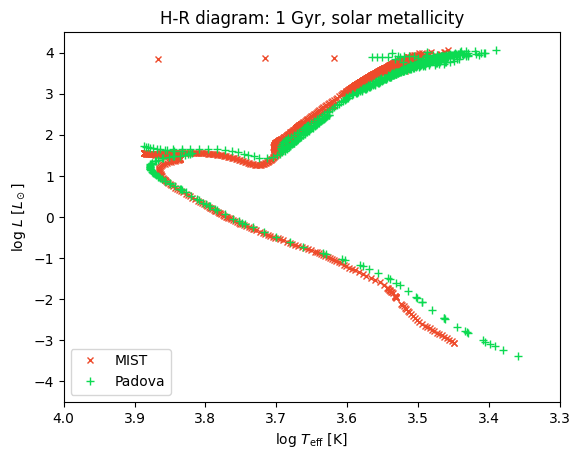

In [26]:
from isoc.plot import plot_isochrone

fig, ax = plot_isochrone(im, x="log_Teff", y="log_L",
                         color='#EE4B2B', marker='x', ls='none', markersize=5, label="MIST")
plot_isochrone(ip, x="log_Teff", y="log_L", ax=ax,
               color='#0BDA51', marker='+', ls='none', label="Padova")

ax.set_xlim(4.0, 3.3)
ax.set_ylim(-4.5, 4.5)
ax.legend(loc='lower left')
ax.set_title("H-R diagram: 1 Gyr, solar metallicity");

### 4.2: Plotting over a grid of ages

(We could also plot isochrones across a metallicity grid for Padova/PARSEC.)

In [27]:
ip_grid = Isochrone.from_padova(
    age=(7.0, 10.0, 0.5),
    metallicity=0.0207,
    metallicity_type="Z",
)

ip_grid.isochrone

Inferred log10 age scale based on age values (7.0, 10.0, 0.5).
'photometry' is None. Using default ezpadova photometric system.


Querying http://stev.oapd.inaf.it/cgi-bin/cmd...
Retrieving data...
User-supplied query parameters (as seen by ezpadova):
	{'age_yr': None, 'logage': (7.0, 10.0, 0.5), 'Z': (0.0207, 0.0207, 0.0), 'MH': None, 'photsys_file': None}
All query parameters (including defaults for those not specified):
	{'age_yr': None, 'logage': (7.0, 10.0, 0.5), 'Z': (0.0207, 0.0207, 0.0), 'MH': None, 'photsys_file': None, 'cmd_version': '3.8', 'track_omegai': '0.00', 'track_parsec': 'parsec_CAF09_v1.2S', 'track_colibri': 'parsec_CAF09_v1.2S_S_LMC_08_web', 'track_postagb': 'no', 'n_inTPC': '10', 'eta_reimers': '0.2', 'kind_interp': '1', 'kind_postagb': '-1', 'photsys_version': 'YBCnewVega', 'dust_sourceM': 'dpmod60alox40', 'dust_sourceC': 'AMCSIC15', 'kind_mag': '2', 'kind_dust': '0', 'extinction_av': '0.0', 'extinction_coeff': 'constant', 'extinction_curve': 'cardelli', 'kind_LP

<IsochroneIndex: 7 isochrone(s): ['log_age=7', 'log_age=7.5', 'log_age=8', 'log_age=8.5', 'log_age=9', 'log_age=9.5', 'log_age=10']>

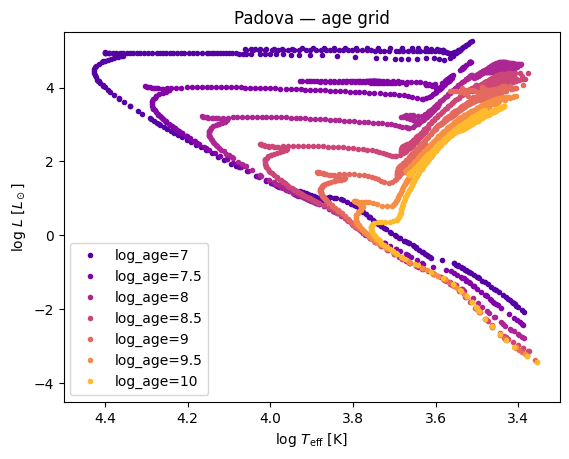

In [28]:
fig, ax = plot_isochrone(
    ip_grid.isochrone,
    iso_labels=ip_grid.isochrone.labels,
    marker='.',
    linestyle='none',
    x="log_Teff",
    y="log_L",
    cmap="plasma",
    )

ax.set_xlim(4.5, 3.3)
ax.set_ylim(-4.5, 5.5)
ax.legend(loc='lower left')
ax.set_title("Padova — age grid");

### 4.3: Color-magnitude diagram

Bmag-Vmag column added to photometry table.


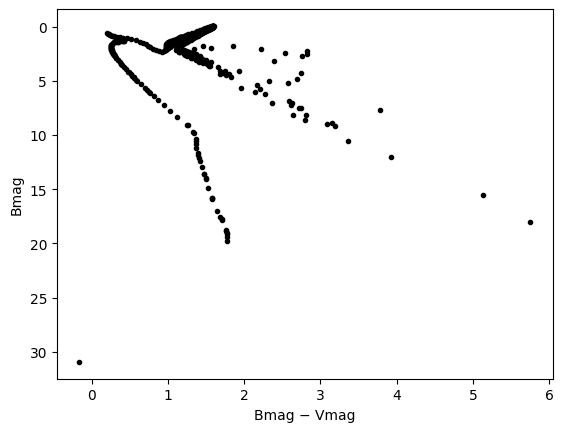

In [29]:
from isoc.plot import plot_color_magnitude

fig, ax = plot_color_magnitude(ip, band1="Bmag", band2="Vmag", mag="Bmag", marker='.', c='k', ls='none')

## 5. Parameter help

Checking the arguments for `from_mist` shows that you can provide an `age` as a float, a list or a tuple for a range (with min, max, step), and you can supply any of these in linear or log space. A few other arguments have generalized names whose corresponding values on the [MIST webform](https://mist.science/interp_isos.html) are given in the docstring, e.g., `metallicity` for "[Fe/H]", `abundance` for "[alpha/Fe]", and `extinction` for "Extinction Av". 

In [30]:
Isochrone.from_mist?

Signature:
Isochrone.from_mist(
    age: tuple[float, float, float] | list | float | None = None,
    metallicity: float | None = None,
    abundance: float | None = None,
    v_div_vcrit: float | None = None,
    photometry: str | None = None,
    extinction: float | None = None,
    version: Literal['MIST1', 'MIST2', None] = None,
    from_file: str | None = None,
    **kwargs,
) -> 'Isochrone'
Docstring:
Query the MIST/MESA service and return an :class:`Isochrone`.

Any parameters passed as ``None`` will use the MIST defaults 
(see `Isochrone.default_values`).

Parameters
----------
age : float, tuple of (low, high, step), list or None
    Age in years or log10(years). A single float queries one isochrone; a tuple of 
    length 3 sets a min, max and step size to query over the corresponding age grid, 
    and a list queries over an age grid.
metallicity : float or None
     [Fe/H] metallicity value.
abundance : float or None
    [alpha/Fe] abundance ratio.
v_div_vcrit : float or No

Checking the arguments for `from_padova`, `age` and `metallicity` generalize and handle multiple input types just as they do in `from_mist` - though for `from_padova` you also have to specify `metallicity_type` as `Z` or `MH`. The `**kwargs` take any [arguments named](https://github.com/mfouesneau/ezpadova/blob/master/src/ezpadova/parsec.md#default-values) in `ezpadova` (which `from_padova` uses as a backend to perform the query).

In [31]:
Isochrone.from_padova?

Signature:
Isochrone.from_padova(
    age: tuple[float, float, float] | float | None = None,
    metallicity: tuple[float, float, float] | float | None = None,
    metallicity_type: Literal['Z', 'MH', None] = None,
    photometry: str | None = None,
    from_file: str | None = None,
    **kwargs,
) -> 'Isochrone'
Docstring:
Query the Padova/PARSEC service and return an :class:`Isochrone`.

Any parameters passed as None will use the Padova/PARSEC defaults 
(see `Isochrone.default_values`).

Parameters
----------
age : tuple of (low, high, step) or float or None
    Age in years or log10(years). A single float queries one isochrone; a tuple of 
    length 3 sets a min, max and step size to query over the corresponding age grid, 
    and a list queries over an age grid.
metallicity : tuple of (low, high, step) or float or None
    Metallicity value. Interpreted as Z or [M/H] depending on metallicity_type.
metallicity_type : str or None
    Whether the metallicity parameter is interpreted 

The arguments to `query_ezpadova` follow the `ezpadova` names and expected types, if you prefer this over using `from_padova`:

In [32]:
Isochrone.query_ezpadova?

Signature:
Isochrone.query_ezpadova(
    age_yr: tuple[float, float, float] | None = None,
    Z: tuple[float, float, float] | None = None,
    logage: tuple[float, float, float] | None = None,
    MH: tuple[float, float, float] | None = None,
    default_ranges: bool = False,
    **kwargs,
) -> 'Isochrone'
Docstring: Query the Padova/PARSEC service and return an :class:`Isochrone`.
File:      ~/Desktop/isoc/isoc/isochrone.py
Type:      method

To understand all available parameters for Padova/PARSEC or MIST/MESA queries and see their defaults (note that these are the parameter names and types expected by the server, not those in `from_mist` or `from_padova`):

In [33]:
print("MIST/MESA:")
print("\nParameter descriptions:")
Isochrone.parameter_descriptions(database="mist")
print("\nDefaults:")
Isochrone.default_values(database="mist")

print("Padova/PARSEC:")
print("\nParameter descriptions:")
Isochrone.parameter_descriptions(database="padova")
print("\nDefaults:")
Isochrone.default_values(database="padova")

MIST/MESA:

Parameter descriptions:
See https://mist.science/interp_isos.html and https://www.mist.science/resources.html

Defaults:


{'v_div_vcrit': 'vvcrit0.4',
 'FeH_value': '0',
 'alpha_value': 'p0',
 'age_value': '',
 'age_range_low': '5',
 'age_range_high': '10.3',
 'age_range_delta': '0.05',
 'Av_value': '0',
 'output_option': 'theory',
 'output': 'UBVRIplus',
 'version': 'MIST2',
 'age_type': 'standard',
 'age_scale': 'log10',
 '_aliases': {'FeH_value': 'metallicity',
  'afe': 'abundance',
  'output': 'photometry',
  'Av_value': 'extinction'}}

Padova/PARSEC:

Parameter descriptions:
See https://stev.oapd.inaf.it/cgi-bin/cmd, https://github.com/mfouesneau/ezpadova/blob/master/src/ezpadova/parsec.md and https://stev.oapd.inaf.it/cmd_3.9/help.html

Defaults:


{'cmd_version': '3.8',
 'track_omegai': '0.00',
 'track_parsec': 'parsec_CAF09_v1.2S',
 'track_colibri': 'parsec_CAF09_v1.2S_S_LMC_08_web',
 'track_postagb': 'no',
 'n_inTPC': '10',
 'eta_reimers': '0.2',
 'kind_interp': '1',
 'kind_postagb': '-1',
 'photsys_file': 'YBC_tab_mag_odfnew/tab_mag_ubvrijhk.dat',
 'photsys_version': 'YBCnewVega',
 'dust_sourceM': 'dpmod60alox40',
 'dust_sourceC': 'AMCSIC15',
 'kind_mag': '2',
 'kind_dust': '0',
 'extinction_av': '0.0',
 'extinction_coeff': 'constant',
 'extinction_curve': 'cardelli',
 'kind_LPV': '3',
 'imf_file': 'tab_imf/imf_kroupa_orig.dat',
 'isoc_isagelog': '0',
 'isoc_agelow': '1.0e9',
 'isoc_ageupp': '1.0e10',
 'isoc_dage': '0.0',
 'isoc_lagelow': '6.6',
 'isoc_lageupp': '10.13',
 'isoc_dlage': '0.0',
 'isoc_ismetlog': '0',
 'isoc_zlow': '0.0152',
 'isoc_zupp': '0.03',
 'isoc_dz': '0.0',
 'isoc_metlow': '-2',
 'isoc_metupp': '0.3',
 'isoc_dmet': '0.0',
 'output_kind': '0',
 'output_evstage': '1',
 'lf_maginf': '-15',
 'lf_magsup': '20